In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

In [39]:
df = pd.read_csv('/kaggle/input/datasets/debajyotipodder/co2-emission-by-vehicles/CO2 Emissions_Canada.csv')


df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

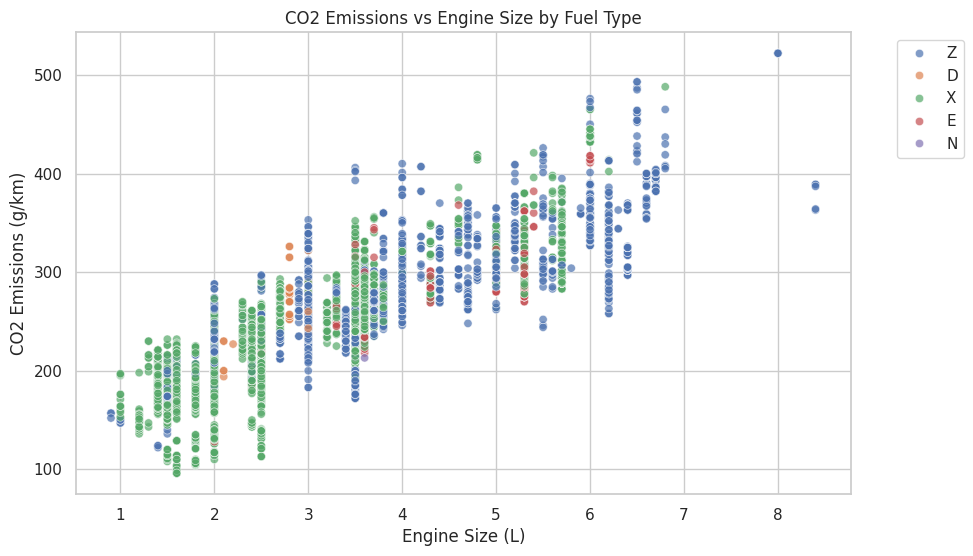

In [41]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Engine Size(L)', y='CO2 Emissions(g/km)', hue='Fuel Type', alpha=0.7)
plt.title('CO2 Emissions vs Engine Size by Fuel Type')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


X = df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)']]
y = df['CO2 Emissions(g/km)']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print('R2 Score:', r2_score(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8773348735033226
RMSE: 20.54074808533515


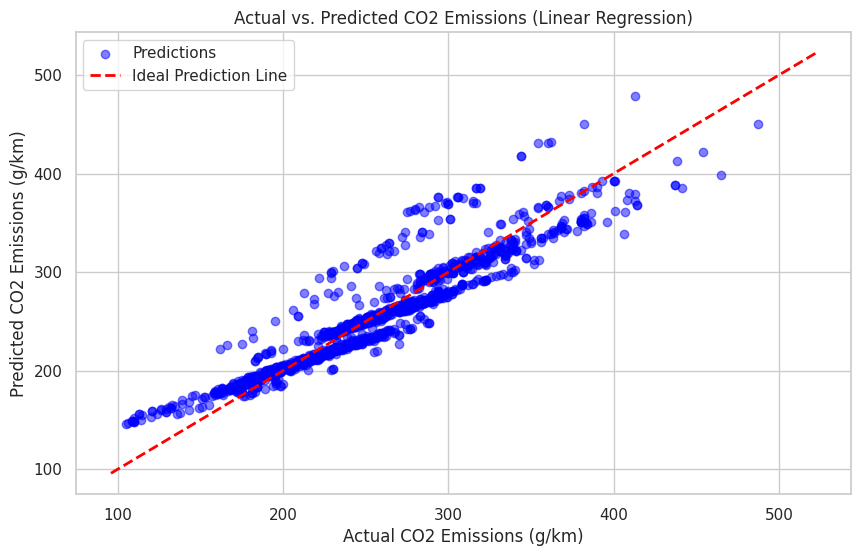

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predictions')

plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, linestyle='--', label='Ideal Prediction Line')

plt.title('Actual vs. Predicted CO2 Emissions (Linear Regression)')
plt.xlabel('Actual CO2 Emissions (g/km)')
plt.ylabel('Predicted CO2 Emissions (g/km)')
plt.legend()
plt.grid(True)
plt.show()

In [45]:
features = ['Engine Size(L)', 'Cylinders', 'Fuel Consumption Comb (L/100 km)', 'Transmission', 'Fuel Type']

X_new = df[features]
y_new = df['CO2 Emissions(g/km)']

X_encoded = pd.get_dummies(X_new, drop_first=True)

X_encoded.head()

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),Transmission_A4,Transmission_A5,Transmission_A6,Transmission_A7,Transmission_A8,Transmission_A9,Transmission_AM5,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,8.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2.4,4,9.6,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,1.5,4,5.9,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,3.5,6,11.1,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3.5,6,10.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_new, test_size=0.2, random_state=42)

new_model = LinearRegression()
new_model.fit(X_train, y_train)

y_pred_new = new_model.predict(X_test)



In [48]:
print('New R2 Score:', r2_score(y_test, y_pred_new))
print('New RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_new)))

New R2 Score: 0.9892386008646877
New RMSE: 6.084012120678086
